**Step 1: Important Libraries**

In [ ]:
import pandas as pd     #for loading and exploring tabular data
import numpy as np       #for numerical operation like mean
import matplotlib.pyplot as plt   #for visualization data and regression line
from sklearn.model_selection import train_test_split  # to split dataset
from sklearn.linear_model import LinearRegression  #for model
from sklearn.metrics import mean_absolute_percentage_error, r2_score #for industry standard matrix that is used for evaluatio

**Stage 2: create and load dataset for Simple Linear Regression**

In [ ]:
## Create 100 values for study hours: 1.0 to 10.0 with 0.1 step

study_hours = [] # empty list to store hours



#Add value manually using a loop
value = 1.0
for i in range(100) :
    study_hours.append(round(value, 1))
    value += 0.1  #increase by 0.1 each time

#create exam_score based on a formula: score = 5 * hours + some small noise

exam_scores = [] # empty list to store scores
#setting random seed  so results are always the same
np.random.seed(42)

for hour in study_hours:
    noise = np.random.normal(0, 4) # small random variation (mean=0, std=4)
    score = 5 * hour + noise
    exam_scores.append(round(score,1)) #round to  1 decimal place


#combine into a dataframe
data = pd.DataFrame({'hours': study_hours, 'score' : exam_scores})

#show first 10 rows
display(data.head(10))

#show total of rows and column
data.shape

,hours,score
0,1.0,7.0
1,1.1,4.9
2,1.2,8.6
3,1.3,12.6
4,1.4,6.1
5,1.5,6.6
6,1.6,14.3
7,1.7,11.6
8,1.8,7.1
9,1.9,11.7


(100, 2)

**Stage 3: Define Features (X) and Target (y)**

In [ ]:
#X = Hours studied → this is what we give to the model
#y = Score achieved → this is what we want the model to predict

X = data[['hours']] #2D format → required by scikit-learn (double square brackets)
y = data['score'] #1D target variable

**Stage 4: Train_test_split**

In [ ]:
# Split into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X,y, #input and output
                                                    test_size = 0.2,
                                                    random_state =2529)
X_train.head()

,hours
46,5.6
53,6.3
3,1.3
66,7.6
26,3.6



**Stage 5: Select & Train the Linear Regression Model**

In [ ]:
#input = hours
#output = scores
#the goal is find y = mx + c that best fit the training data
# Create the model
model = LinearRegression()

# Train (fit) the model on the training data
model.fit(X_train, y_train)

LinearRegression()

**Stage 6: Get Slope and Intercept**
- m = Slope (how much the score increases for each extra hour studied)
- c = Intercept (predicted score when study hours = 0)

In [ ]:
slope = model.coef_[0]
intercept = model.intercept_
slope
intercept

np.float64(-1.0935842416968278)

**Stage 7: Predict on the Test Data**

In [ ]:
#make prediction on the x test
y = model.predict(X_test)


#show 5 predictation on actual score
results = pd.DataFrame({'Hours': X_test.squeeze(), 'Actual Score': y_test, 'Predicted Score': y.round(1)})
results.head()

,Hours,Actual Score,Predicted Score
93,10.3,50.2,51.6
9,1.9,11.7,8.6
82,9.2,51.9,46.0
81,9.1,46.9,45.5
27,3.7,20.0,17.8


**Stage 8: Evaluate Model Performance**
- MAPE= 1/n * Σ
- 📊 1. Mean Absolute Percentage Error (MAPE) (alt+228 = Σ)
- 1/n * Σ|actual-predicted|/actual *100
- Shows how far off predictions are, on average, as a %
- Lower MAPE = better model

**R² Score (Coefficient of Determination)**
- Ranges from 0 to 1
- Measures how well the regression line explains the variation in actual scores

In [ ]:
mape = mean_absolute_percentage_error(y_test, y)
r2 = r2_score(y_test, y)
mape
r2

0.9432933688442857

**Stage 9: Visualize the Best Fit Line**

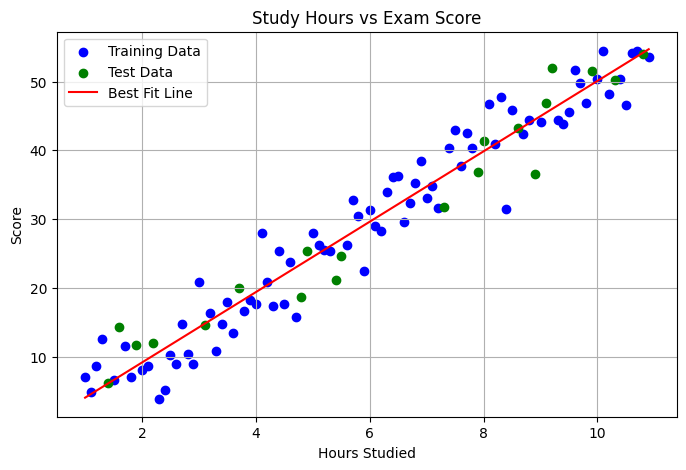

In [ ]:
# Make sure plots show up in notebook
%matplotlib inline
import matplotlib.pyplot as plt

#Visualize the best fit line

plt.figure(figsize=(8, 5))

# Plot training data
plt.scatter(X_train, y_train, color='blue', label='Training Data')

# Plot test data
plt.scatter(X_test, y_test, color='green', label='Test Data')

# Plot regression line over entire data range
line = model.predict(X)  # predict across all X for smooth line
plt.plot(X, line, color='red', label='Best Fit Line')

# Labels and legend
plt.title("Study Hours vs Exam Score")
plt.xlabel("Hours Studied")
plt.ylabel("Score")
plt.legend()
plt.grid(True)
plt.show()